## DATOS OBSERVADOS

### Sacando el expenditure suponiendo una demanda fija

In [35]:
import pandas as pd

precio_horario = pd.read_csv('../datos/raw/Preciodebolsahorario.csv')
filtro = (precio_horario['CodigoVariable'] == 'PB_Int') & (precio_horario['Version'] == 'TXF')
precio_horario = precio_horario[filtro]
precio_horario.head()

,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,Version,Valor
288,PB_Int,2025-06-01 00:00:00,PT1H,COP/kWh,TXF,101.2
289,PB_Int,2025-06-01 01:00:00,PT1H,COP/kWh,TXF,101.2
290,PB_Int,2025-06-01 02:00:00,PT1H,COP/kWh,TXF,101.2
291,PB_Int,2025-06-01 03:00:00,PT1H,COP/kWh,TXF,101.2
292,PB_Int,2025-06-01 04:00:00,PT1H,COP/kWh,TXF,101.2


In [36]:
CSV_PATH = "../results/fechas_117/TERMICA/inputRed2.csv"   # <-- adjust
despacho = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal="."     # si tienes 1.234.567,89
)
despacho.columns = despacho.columns.str.strip() 
demand_raw = despacho['daily_reman_demand'].dropna().iloc[1657]  # tomo la fila 1657 que tiene demanda completa, pero podría ser cualquier fila con demanda válida


In [37]:
demand_raw

' [933510.0, 813000.0, 813000.0, 659000.0, 659000.0, 635000.0, 662930.0, 635000.0, 634000.0, 654000.0, 668000.0, 676000.0, 661000.0, 670000.0, 810870.0, 981560.0, 1090250.0, 942000.0, 1370010.0, 1519400.0, 1624740.0, 1303260.0, 1306070.0, 1183070.0]'

In [38]:
import pandas as pd

demand_raw = [933510.0, 813000.0, 813000.0, 659000.0, 659000.0, 635000.0,
              662930.0, 635000.0, 634000.0, 654000.0, 668000.0, 676000.0,
              661000.0, 670000.0, 810870.0, 981560.0, 1090250.0, 942000.0,
              1370010.0, 1519400.0, 1624740.0, 1303260.0, 1306070.0, 1183070.0]

cantidades_fija = pd.DataFrame({
    "hora": range(24),
    "valor": demand_raw
})

print(cantidades_fija)

    hora      valor
0      0   933510.0
1      1   813000.0
2      2   813000.0
3      3   659000.0
4      4   659000.0
5      5   635000.0
6      6   662930.0
7      7   635000.0
8      8   634000.0
9      9   654000.0
10    10   668000.0
11    11   676000.0
12    12   661000.0
13    13   670000.0
14    14   810870.0
15    15   981560.0
16    16  1090250.0
17    17   942000.0
18    18  1370010.0
19    19  1519400.0
20    20  1624740.0
21    21  1303260.0
22    22  1306070.0
23    23  1183070.0


In [39]:
precio_horario=precio_horario[['FechaHora', 'Valor']].copy()
precio_horario.rename(columns={'Valor': 'precio'}, inplace=True)


In [40]:

# Asegurarnos que FechaHora es datetime
precio_horario["FechaHora"] = pd.to_datetime(precio_horario["FechaHora"])

# Sacar la hora (0–23)
precio_horario["hora"] = precio_horario["FechaHora"].dt.hour
precio_horario["fecha"] = precio_horario["FechaHora"].dt.date
df_expenditure_obs = cantidades_fija.merge(precio_horario, on="hora")
df_expenditure_obs['expenditure_h'] = df_expenditure_obs["precio"] * df_expenditure_obs["valor"]


In [41]:
import pandas as pd


# Calcular el mean por hora
df_mean= (
    df_expenditure_obs
    .groupby("fecha")["expenditure_h"]   # cambia "valor" por el nombre real de tu columna numérica
    .sum()
    .reset_index(name="expenditure_day")
)

df_mean

,fecha,expenditure_day
0,2025-04-01,5.825701e+09
1,2025-04-02,5.155027e+09
2,2025-04-03,5.475533e+09
3,2025-04-04,4.082571e+09
4,2025-04-05,2.552071e+09
...,...,...
157,2025-09-05,8.068586e+09
158,2025-09-06,3.308190e+09
159,2025-09-07,2.288523e+09
160,2025-09-08,6.992402e+09


In [42]:
df_mean.describe()

,expenditure_day
count,1.620000e+02
mean,3.743052e+09
std,1.930753e+09
min,2.216534e+09
25%,2.304236e+09
50%,2.835725e+09
75%,4.513705e+09
max,1.121792e+10


In [43]:
df_mean.describe()/1000000000
# 3.74 millones, se mantiene teniendo la demanda fija y no dija

,expenditure_day
count,1.620000e-07
mean,3.743052e+00
std,1.930753e+00
min,2.216534e+00
25%,2.304236e+00
50%,2.835725e+00
75%,4.513705e+00
max,1.121792e+01


## Usando toda la demanda y precio horario normal

In [44]:
despacho['CodigoPlanta'] = despacho['CodigoPlanta'].astype(str).str.strip()
despacho['CodigoPlanta'].unique().tolist()

['3ENA',
 'CTG1',
 'CTG2',
 'GE32',
 'GEC3',
 'MRL1',
 'PPA1',
 'PPA2',
 'PPA3',
 'PPA4',
 'PRG1',
 'PRG2',
 'TBQ3',
 'TBQ4',
 'TBST',
 'TCDT',
 'TDR1',
 'TEC1',
 'TFL1',
 'TFL4',
 'TGJ1',
 'TGJ2',
 'TRM1',
 'TRN1',
 'TSJ1',
 'TSJ2',
 'TSR1',
 'TVL1',
 'TYP1',
 'TYP2',
 'TYP3',
 'TYP4',
 'ZPA2',
 'ZPA3',
 'ZPA4',
 'ZPA5']

In [45]:
import pandas as pd

despacho_obs = pd.read_csv('../datos/raw/Despachoprogramadorecursosdegeneracion.csv', sep=',')

despacho_termicas = despacho_obs[
    (despacho_obs['CodigoElementoGeneracion'].isin(despacho['CodigoPlanta'])) &
    (despacho_obs['Valor'] > 0)
].copy() 


# Asegurarse de que FechaHora es datetime en ambos
despacho_termicas['FechaHora'] = pd.to_datetime(despacho_termicas['FechaHora'])
precio_horario['FechaHora'] = pd.to_datetime(precio_horario['FechaHora'])

# Merge por FechaHora
df_merged = despacho_termicas.merge(
    precio_horario[['FechaHora', 'precio']],
    on='FechaHora',
    how='left',
    suffixes=('_despacho', '_precio')
)

# Multiplicar los valores
df_merged['Producto'] = df_merged['Valor'] * df_merged['precio']


# Aseguramos que FechaHora sea datetime
df_merged['FechaHora'] = pd.to_datetime(df_merged['FechaHora'])

# Extraemos solo la fecha
df_merged['Fecha'] = df_merged['FechaHora'].dt.date

# Suma diaria por fecha (ya la tienes)
suma_diaria = df_merged.groupby('Fecha')['Producto'].sum()

# Promedio de la suma diaria
promedio_total = suma_diaria.mean()

# Desviación estándar de la suma diaria
desviacion_total = suma_diaria.std()

print("Suma diaria por fecha:")
print(suma_diaria)

print("\nPromedio de la suma diaria de Producto:", promedio_total)
print("Desviación estándar de la suma diaria de Producto:", desviacion_total)

Suma diaria por fecha:
Fecha
2025-04-01    5.296467e+09
2025-04-02    4.984987e+09
2025-04-03    5.151035e+09
2025-04-04    3.460878e+09
2025-04-05    2.135100e+09
                  ...     
2025-09-05    1.012163e+10
2025-09-06    3.316063e+09
2025-09-07    1.990620e+09
2025-09-08    6.318353e+09
2025-09-09    7.780160e+09
Name: Producto, Length: 162, dtype: float64

Promedio de la suma diaria de Producto: 3752398877.6580243
Desviación estándar de la suma diaria de Producto: 2719833019.1779675


In [46]:
df_merged = despacho_termicas.merge(
    precio_horario[['FechaHora', 'precio']],
    on='FechaHora',
    how='left',
    suffixes=('_despacho', '_precio')
)
df_merged

,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor,precio
0,2025-08-11 00:00:00,PT1H,TRN1,62000,102.82
1,2025-08-11 00:00:00,PT1H,TYP1,8000,102.82
2,2025-08-11 00:00:00,PT1H,TYP2,27000,102.82
3,2025-08-11 00:00:00,PT1H,ZPA2,17000,102.82
4,2025-08-11 01:00:00,PT1H,TBST,234000,102.82
...,...,...,...,...,...
35315,2025-04-05 22:00:00,PT1H,TGJ2,72000,112.68
35316,2025-04-05 22:00:00,PT1H,TRN1,62000,112.68
35317,2025-04-05 22:00:00,PT1H,TYP1,8000,112.68
35318,2025-04-05 22:00:00,PT1H,TYP3,49000,112.68


In [47]:
suma_diaria.describe()/1000000000

count    1.620000e-07
mean     3.752399e+00
std      2.719833e+00
min      1.630958e+00
25%      2.099962e+00
50%      2.656371e+00
75%      4.143335e+00
max      1.652674e+01
Name: Producto, dtype: float64

In [48]:
#miles de millones, en promedio para un dia de mi periodo!!
promedio_total/1000000000

np.float64(3.7523988776580244)

## Grafica de precios (OBSERVADO) con mi simulacion (NPGA)

In [49]:
precio_horario = precio_horario.sort_values(by="FechaHora")

In [50]:
precio_horario

,FechaHora,precio,hora,fecha
4248,2025-04-01 00:00:00,162.38,0,2025-04-01
4249,2025-04-01 01:00:00,162.38,1,2025-04-01
4250,2025-04-01 02:00:00,162.38,2,2025-04-01
4251,2025-04-01 03:00:00,162.38,3,2025-04-01
4252,2025-04-01 04:00:00,162.38,4,2025-04-01
...,...,...,...,...
9019,2025-09-09 19:00:00,875.07,19,2025-09-09
9020,2025-09-09 20:00:00,875.07,20,2025-09-09
9021,2025-09-09 21:00:00,255.14,21,2025-09-09
9022,2025-09-09 22:00:00,110.67,22,2025-09-09


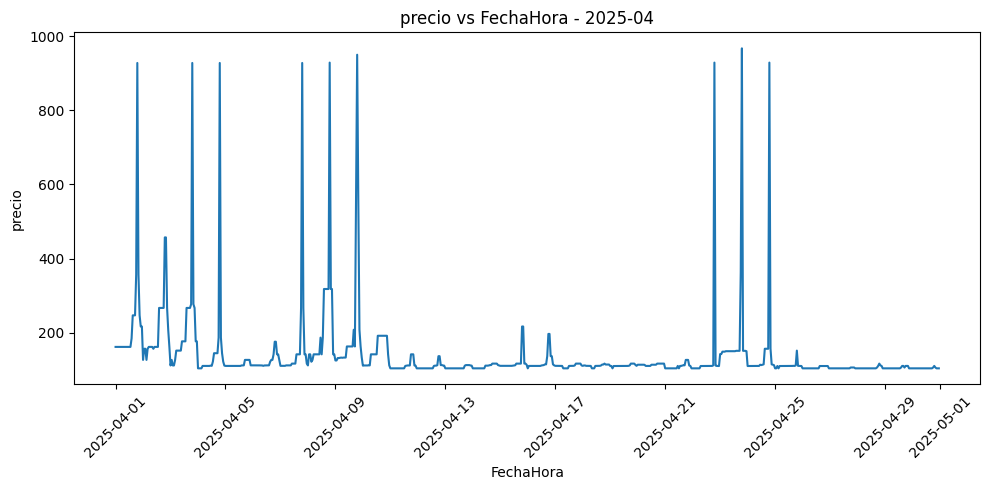

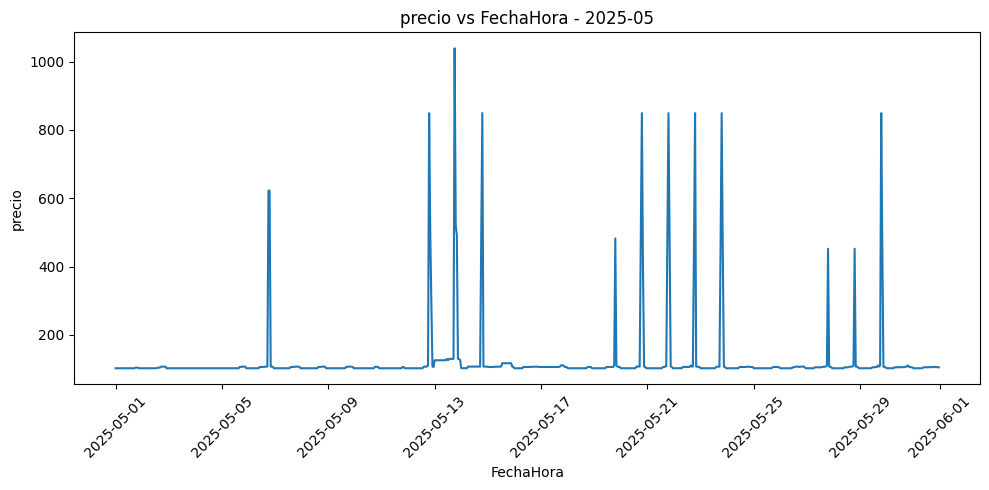

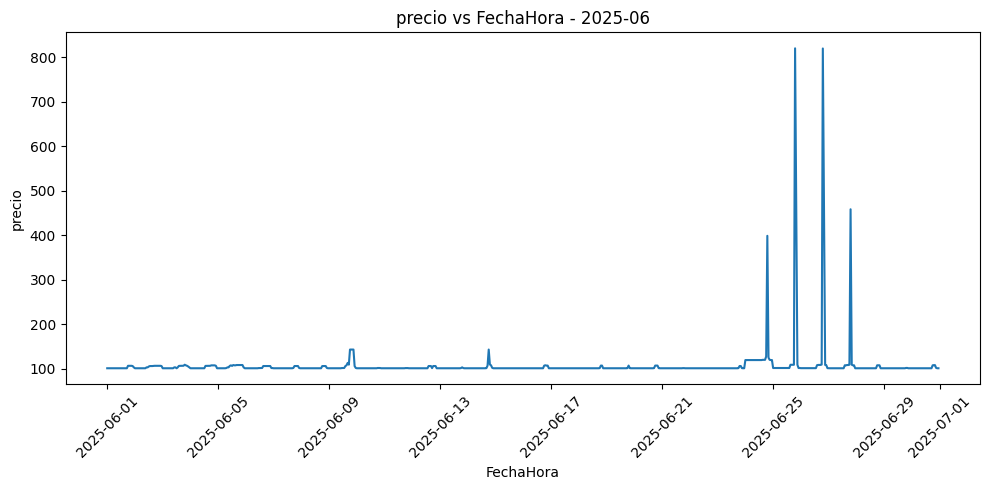

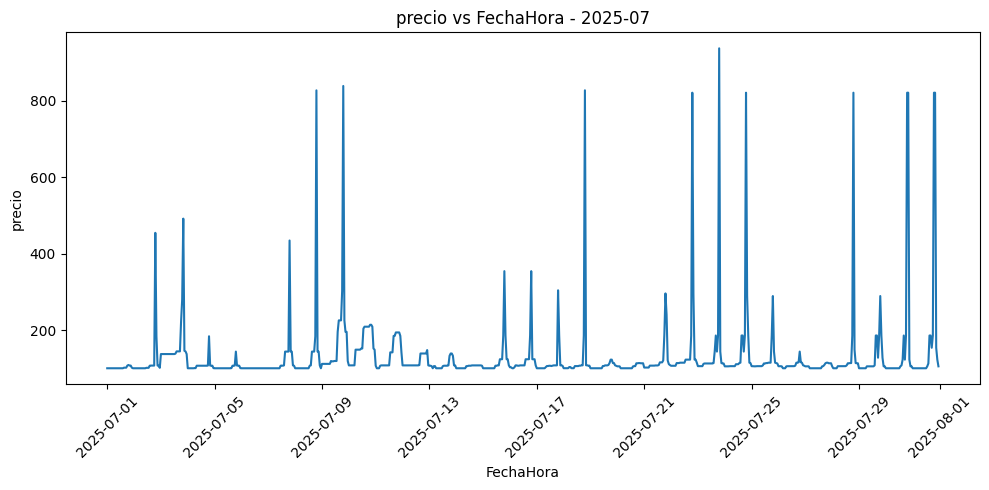

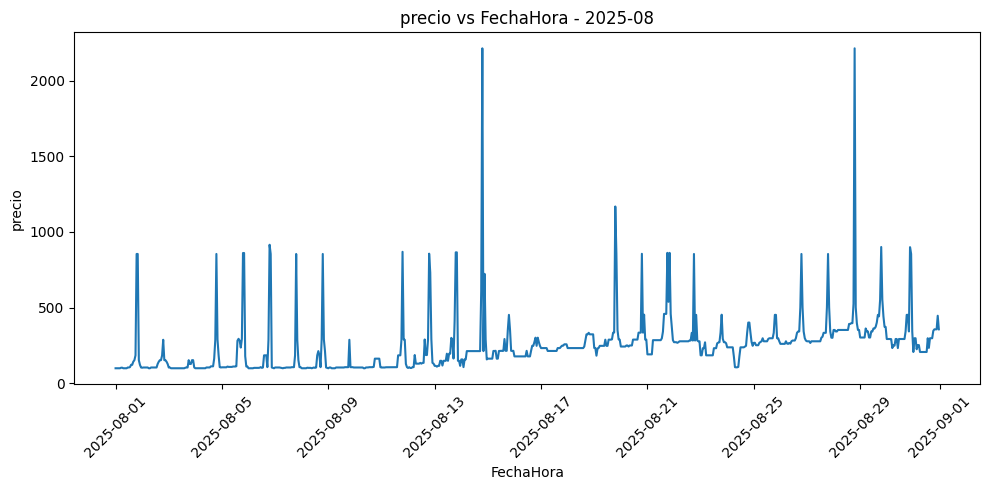

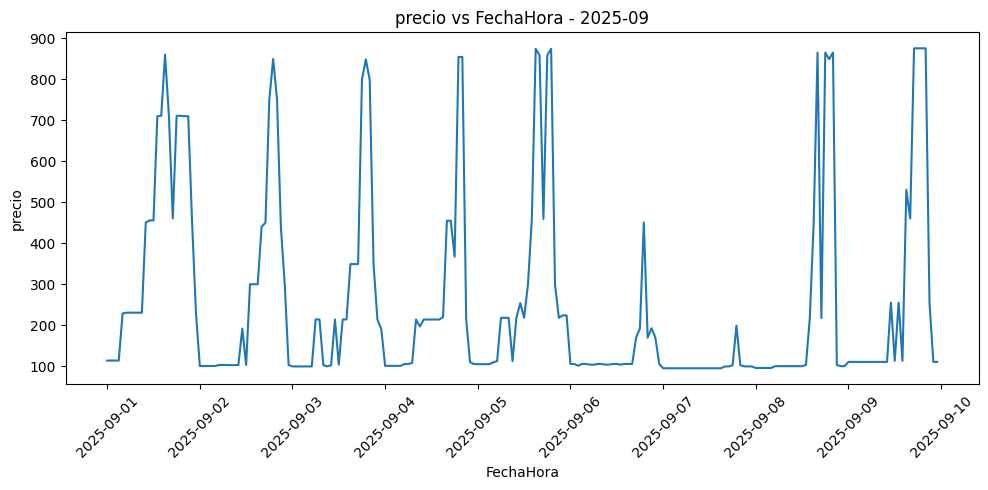

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar formato datetime
precio_horario["FechaHora"] = pd.to_datetime(precio_horario["FechaHora"])

# Crear columna Año-Mes
precio_horario["AñoMes"] = precio_horario["FechaHora"].dt.to_period("M")

# Agrupar por mes
for periodo, datos_mes in precio_horario.groupby("AñoMes"):
    
    plt.figure(figsize=(10,5))
    plt.plot(datos_mes["FechaHora"], datos_mes["precio"])
    
    plt.xlabel("FechaHora")
    plt.ylabel("precio")
    plt.title(f"precio vs FechaHora - {periodo}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## solo 18 a 21 horas

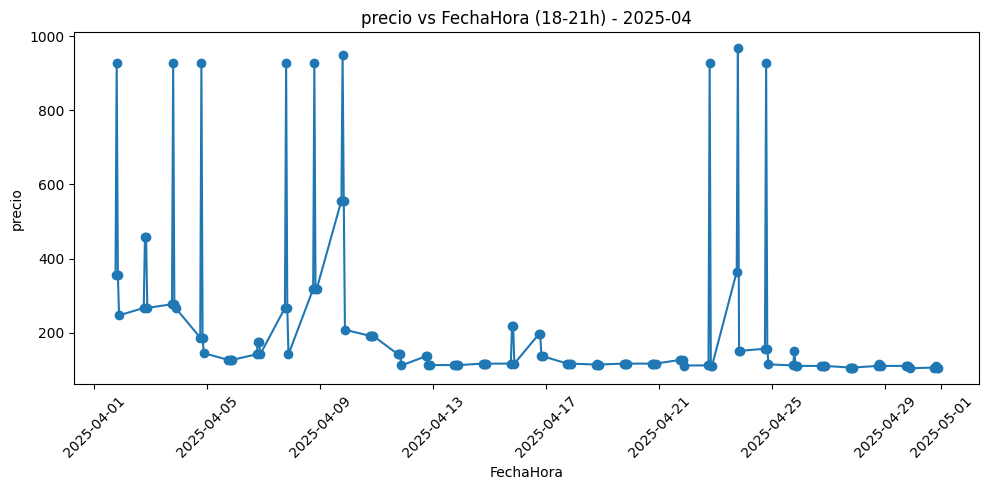

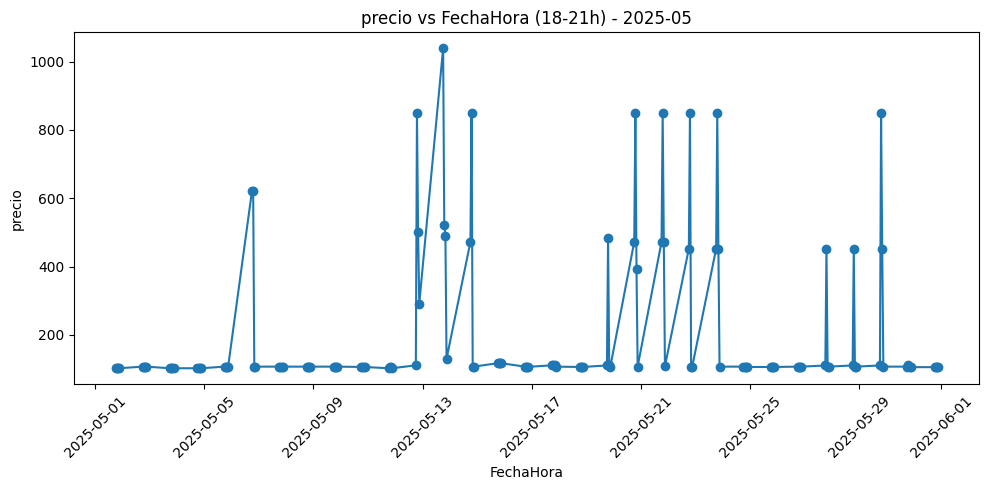

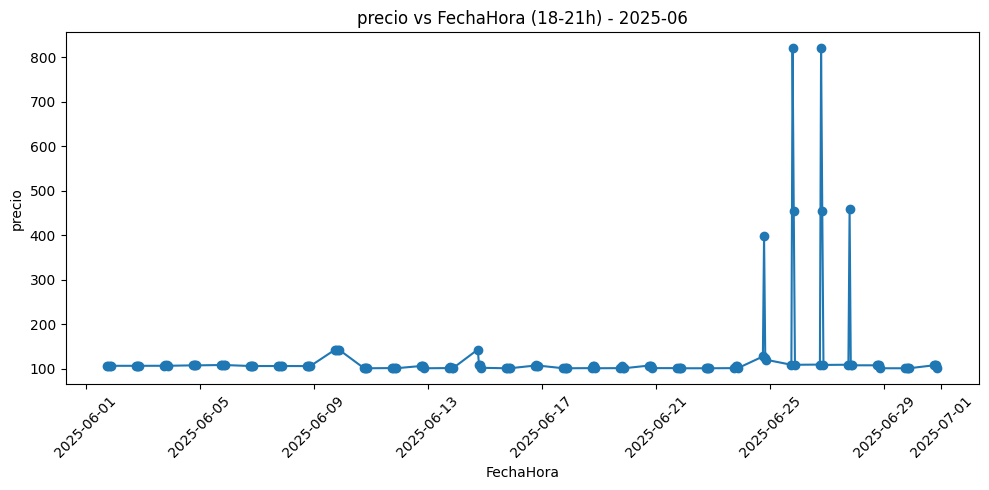

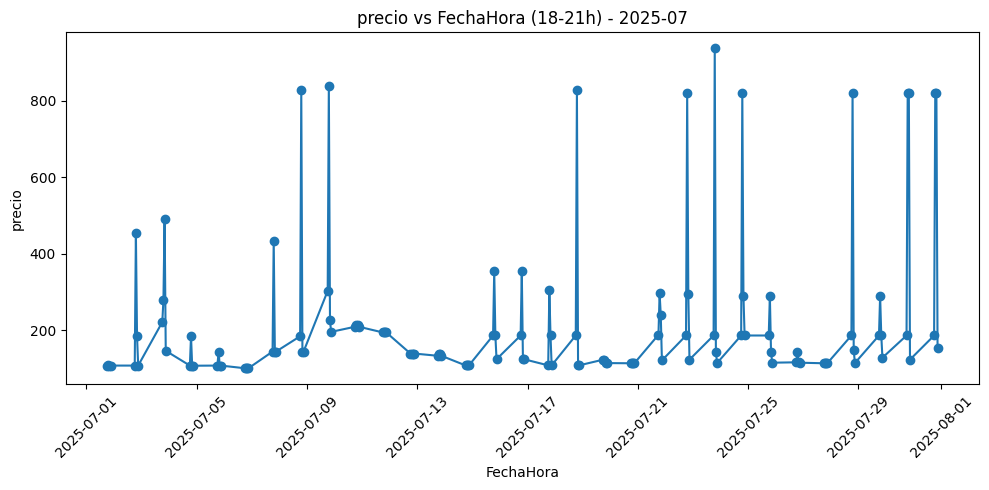

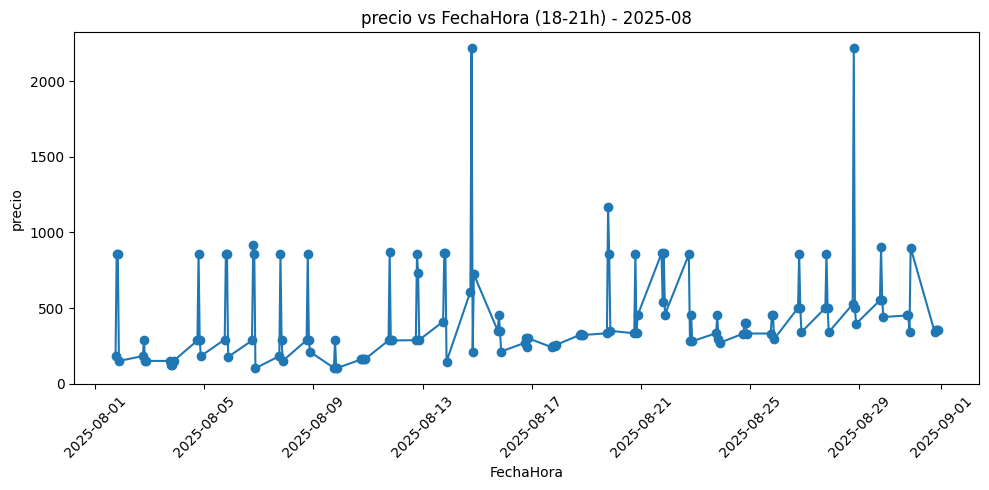

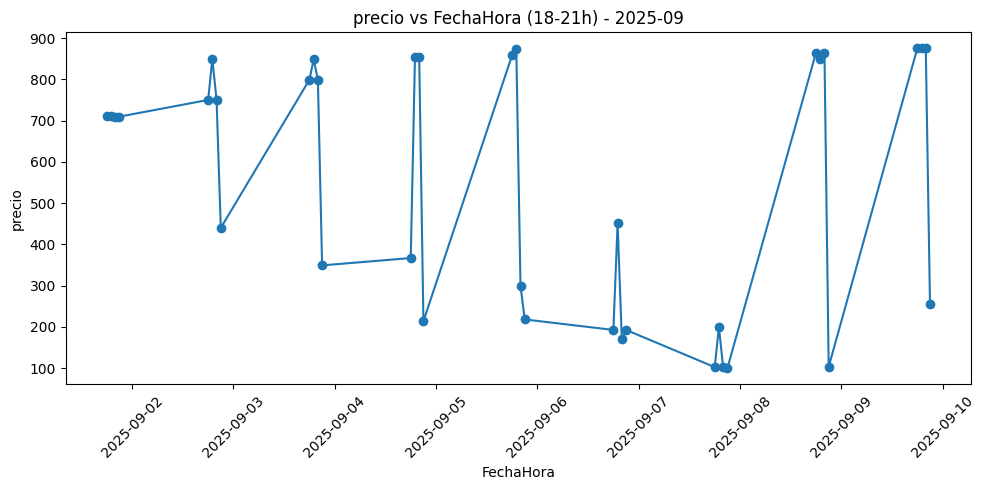

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar formato datetime
precio_horario["FechaHora"] = pd.to_datetime(precio_horario["FechaHora"])

# Filtrar horas entre 18 y 21
precio_filtrado = precio_horario[
    precio_horario["FechaHora"].dt.hour.between(18, 21)
]

# Crear columna Año-Mes
precio_filtrado["AñoMes"] = precio_filtrado["FechaHora"].dt.to_period("M")

# Agrupar por mes
for periodo, datos_mes in precio_filtrado.groupby("AñoMes"):
    
    plt.figure(figsize=(10,5))
    plt.plot(datos_mes["FechaHora"], datos_mes["precio"], marker="o")
    
    plt.xlabel("FechaHora")
    plt.ylabel("precio")
    plt.title(f"precio vs FechaHora (18-21h) - {periodo}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [53]:
precio_horario

,FechaHora,precio,hora,fecha,AñoMes
4248,2025-04-01 00:00:00,162.38,0,2025-04-01,2025-04
4249,2025-04-01 01:00:00,162.38,1,2025-04-01,2025-04
4250,2025-04-01 02:00:00,162.38,2,2025-04-01,2025-04
4251,2025-04-01 03:00:00,162.38,3,2025-04-01,2025-04
4252,2025-04-01 04:00:00,162.38,4,2025-04-01,2025-04
...,...,...,...,...,...
9019,2025-09-09 19:00:00,875.07,19,2025-09-09,2025-09
9020,2025-09-09 20:00:00,875.07,20,2025-09-09,2025-09
9021,2025-09-09 21:00:00,255.14,21,2025-09-09,2025-09
9022,2025-09-09 22:00:00,110.67,22,2025-09-09,2025-09


## EMPIEZA VERIFICACION PRECIOS

In [54]:
import pandas as pd

precio_horario = pd.read_csv('../datos/raw/Preciodebolsahorario.csv')
filtro = (precio_horario['CodigoVariable'] == 'PB_Int') & (precio_horario['Version'] == 'TXF')
precio_horario = precio_horario[filtro]
precio_horario["FechaHora"] = pd.to_datetime(precio_horario["FechaHora"])

# Sacar la hora (0–23)
precio_horario["hora"] = precio_horario["FechaHora"].dt.hour
precio_horario["fecha"] = precio_horario["FechaHora"].dt.date

In [55]:

precio_horario.rename(columns={'Valor': 'precioObservado'}, inplace=True)

## plnatilla precio

In [56]:
CSV_PATH = "../results/fechas_117/TERMICA/inputRed2.csv"   # <-- adjust
df = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal="."     # si tienes 1.234.567,89
)
df.columns = df.columns.str.strip() 
df = df.sort_values("Fecha").reset_index(drop=True)
df["h"] = (df["Fecha"].rank(method="dense") - 1).astype(int)

## panel uniforme red 5 

In [57]:
panel5_median=pd.read_csv("symmetric/5redespromedio/panel_uniform.csv")

In [58]:
panel5_median=panel5_median.merge(df[['h', 'Fecha', 'id_planta']], on=["h", 'id_planta'], how="left")

In [59]:
panel5_median

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi,Fecha
0,1,0,0,0.881223,"[50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 50....","[1.0626533031463623, 1.0626533031463623, 1.062...","[0.07175805856629999, 0.07175805856629999, 0.0...",2025-04-01
1,2,0,0,1.785705,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9466334040629999, 0.9466334040629999, 0.946...",2025-04-01
2,3,0,0,1.067378,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2283073328238, 0.2283073328238, 0.228307332...",2025-04-01
3,4,0,0,1.062653,"[138.51, 18.0, 18.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0626533031463623, 1.0626533031463623, 1.062...","[0.2235823991822, 0.2235823991822, 0.223582399...",2025-04-01
4,5,0,0,2.218085,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9730122853209, 0.9730122853209, 0.973012285...",2025-04-01
...,...,...,...,...,...,...,...,...
4207,32,0,116,2.106840,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8617673362902, 0.8617673362902, 0.861767336...",2025-09-09
4208,33,0,116,2.464132,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.2190602927523, 1.2190602927523, 1.219060292...",2025-09-09
4209,34,0,116,2.467448,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.2223766098828, 1.2223766098828, 1.222376609...",2025-09-09
4210,35,0,116,2.343359,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0982876247439002, 1.0982876247439002, 1.098...",2025-09-09


In [60]:
import pandas as pd
import numpy as np

# Asegurarse que precio24 es string y convertir a lista de floats
panel5_median["precio24_list"] = panel5_median["precio24"].astype(str).apply(
    lambda x: [float(v) for v in x.strip("[]").split(",")]
)

resultados = []

# Agrupar por fecha
for fecha, grupo in panel5_median.groupby("Fecha"):
    
    # Convertir lista de listas a array 2D: filas=plantas, columnas=24 componentes
    arr = np.array(grupo["precio24_list"].to_list())
    
    # Tomar máximo por columna (cada componente)
    max_por_hora = arr.max(axis=0)
    
    # Crear fechas horarias para esa fecha
    horas = pd.date_range(start=pd.to_datetime(fecha), periods=len(max_por_hora), freq="h")
    
    df_temp = pd.DataFrame({
        "FechaHora": horas,
        "precioCierreMedian5": max_por_hora
    })
    
    resultados.append(df_temp)

# Concatenar todos los resultados
precioCierre_df_median5 = pd.concat(resultados, ignore_index=True)


In [61]:
precioCierre_df_median5

,FechaHora,precioCierreMedian5
0,2025-04-01 00:00:00,1.062653
1,2025-04-01 01:00:00,1.062653
2,2025-04-01 02:00:00,1.062653
3,2025-04-01 03:00:00,1.004073
4,2025-04-01 04:00:00,1.004073
...,...,...
2803,2025-09-09 19:00:00,1.197740
2804,2025-09-09 20:00:00,1.197740
2805,2025-09-09 21:00:00,1.197740
2806,2025-09-09 22:00:00,1.197740


## panel 5 uniforme red promedio

In [62]:

panel5_promedio=pd.read_csv("symmetric/5redespromedio/panel_uniform.csv")
panel5_promedio=panel5_promedio.merge(df[['h', 'Fecha']], on="h", how="left")

panel5_promedio["precio24_list"] = panel5_promedio["precio24"].astype(str).apply(
    lambda x: [float(v) for v in x.strip("[]").split(",")]
)

resultados = []

# Agrupar por fecha
for fecha, grupo in panel5_promedio.groupby("Fecha"):
    
    # Convertir lista de listas a array 2D: filas=plantas, columnas=24 componentes
    arr = np.array(grupo["precio24_list"].to_list())
    
    # Tomar máximo por columna (cada componente)
    max_por_hora = arr.max(axis=0)
    
    # Crear fechas horarias para esa fecha
    horas = pd.date_range(start=pd.to_datetime(fecha), periods=len(max_por_hora), freq="h")
    
    df_temp = pd.DataFrame({
        "FechaHora": horas,
        "precioCierrePromedio5": max_por_hora
    })
    
    resultados.append(df_temp)

# Concatenar todos los resultados
precioCierre_df_promedio5 = pd.concat(resultados, ignore_index=True)

In [63]:
precioCierre_df_promedio5

,FechaHora,precioCierrePromedio5
0,2025-04-01 00:00:00,1.062653
1,2025-04-01 01:00:00,1.062653
2,2025-04-01 02:00:00,1.062653
3,2025-04-01 03:00:00,1.004073
4,2025-04-01 04:00:00,1.004073
...,...,...
2803,2025-09-09 19:00:00,1.197740
2804,2025-09-09 20:00:00,1.197740
2805,2025-09-09 21:00:00,1.197740
2806,2025-09-09 22:00:00,1.197740


## panel uniforme 1 red mean

In [64]:

panel1_median=pd.read_csv("symmetric/1redmedian/panel_uniform.csv")
panel1_median=panel1_median.merge(df[['h', 'Fecha']], on="h", how="left")

panel1_median["precio24_list"] = panel1_median["precio24"].astype(str).apply(
    lambda x: [float(v) for v in x.strip("[]").split(",")]
)

resultados = []

# Agrupar por fecha
for fecha, grupo in panel1_median.groupby("Fecha"):
    
    # Convertir lista de listas a array 2D: filas=plantas, columnas=24 componentes
    arr = np.array(grupo["precio24_list"].to_list())
    
    # Tomar máximo por columna (cada componente)
    max_por_hora = arr.max(axis=0)
    
    # Crear fechas horarias para esa fecha
    horas = pd.date_range(start=pd.to_datetime(fecha), periods=len(max_por_hora), freq="h")
    
    df_temp = pd.DataFrame({
        "FechaHora": horas,
        "precioCierreMedian1": max_por_hora
    })
    
    resultados.append(df_temp)

# Concatenar todos los resultados
precioCierre_df_median1 = pd.concat(resultados, ignore_index=True)

FileNotFoundError: [Errno 2] No such file or directory: 'symmetric/1redmedian/panel_uniform.csv'

## comparacion

In [65]:
precioCierreComparacion=precioCierre_df_median5.merge(precio_horario[['FechaHora', 'precioObservado']], on="FechaHora", how="left")

In [66]:
precioCierre_df_median5

,FechaHora,precioCierreMedian5
0,2025-04-01 00:00:00,1.062653
1,2025-04-01 01:00:00,1.062653
2,2025-04-01 02:00:00,1.062653
3,2025-04-01 03:00:00,1.004073
4,2025-04-01 04:00:00,1.004073
...,...,...
2803,2025-09-09 19:00:00,1.197740
2804,2025-09-09 20:00:00,1.197740
2805,2025-09-09 21:00:00,1.197740
2806,2025-09-09 22:00:00,1.197740


In [67]:
precioCierreComparacion['precioObservado']=precioCierreComparacion['precioObservado']/1000
precioCierreComparacion=precioCierreComparacion.merge(precioCierre_df_promedio5, on="FechaHora", how="left")
#precioCierreComparacion=precioCierreComparacion.merge(precioCierre_df_median1, on="FechaHora", how="left")
precioCierreComparacion

,FechaHora,precioCierreMedian5,precioObservado,precioCierrePromedio5
0,2025-04-01 00:00:00,1.062653,0.16238,1.062653
1,2025-04-01 01:00:00,1.062653,0.16238,1.062653
2,2025-04-01 02:00:00,1.062653,0.16238,1.062653
3,2025-04-01 03:00:00,1.004073,0.16238,1.004073
4,2025-04-01 04:00:00,1.004073,0.16238,1.004073
...,...,...,...,...
2803,2025-09-09 19:00:00,1.197740,0.87507,1.197740
2804,2025-09-09 20:00:00,1.197740,0.87507,1.197740
2805,2025-09-09 21:00:00,1.197740,0.25514,1.197740
2806,2025-09-09 22:00:00,1.197740,0.11067,1.197740


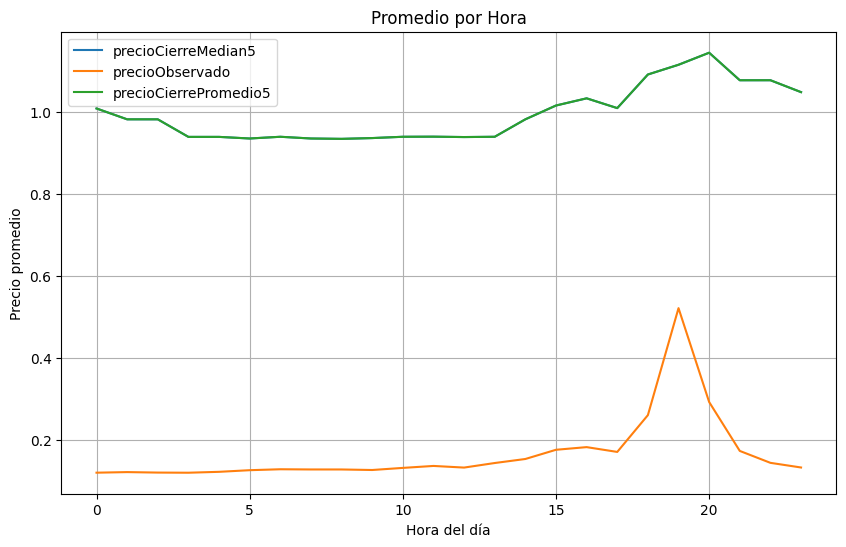

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar formato datetime
precioCierreComparacion["FechaHora"] = pd.to_datetime(
    precioCierreComparacion["FechaHora"]
)

# Extraer hora
precioCierreComparacion["Hora"] = precioCierreComparacion["FechaHora"].dt.hour
columnas = [
    "precioCierreMedian5",
    "precioObservado",
    "precioCierrePromedio5"
]

df_promedio = (
    precioCierreComparacion
    .groupby("Hora")[columnas]
    .mean()
    .sort_index()
)
plt.figure(figsize=(10,6))

for col in columnas:
    plt.plot(df_promedio.index, df_promedio[col], label=col)

plt.title("Promedio por Hora")
plt.xlabel("Hora del día")
plt.ylabel("Precio promedio")
plt.legend()
plt.grid(True)
plt.show()

## ESTA SI ES LA QUE SIRVE PORQUE LA QUE ES 1  A 1 ESA NO, PORQUE ES QUE CUANDO ENTRENO LA RED EN T=1, USO TODO PORQUE MIS BATCHES ES USAR DESDE 2025-01-01 A 2025-09-09 ENTONCES SIEMPRE ME VA A DAR POR ARRIBA ME ENTIENDES?

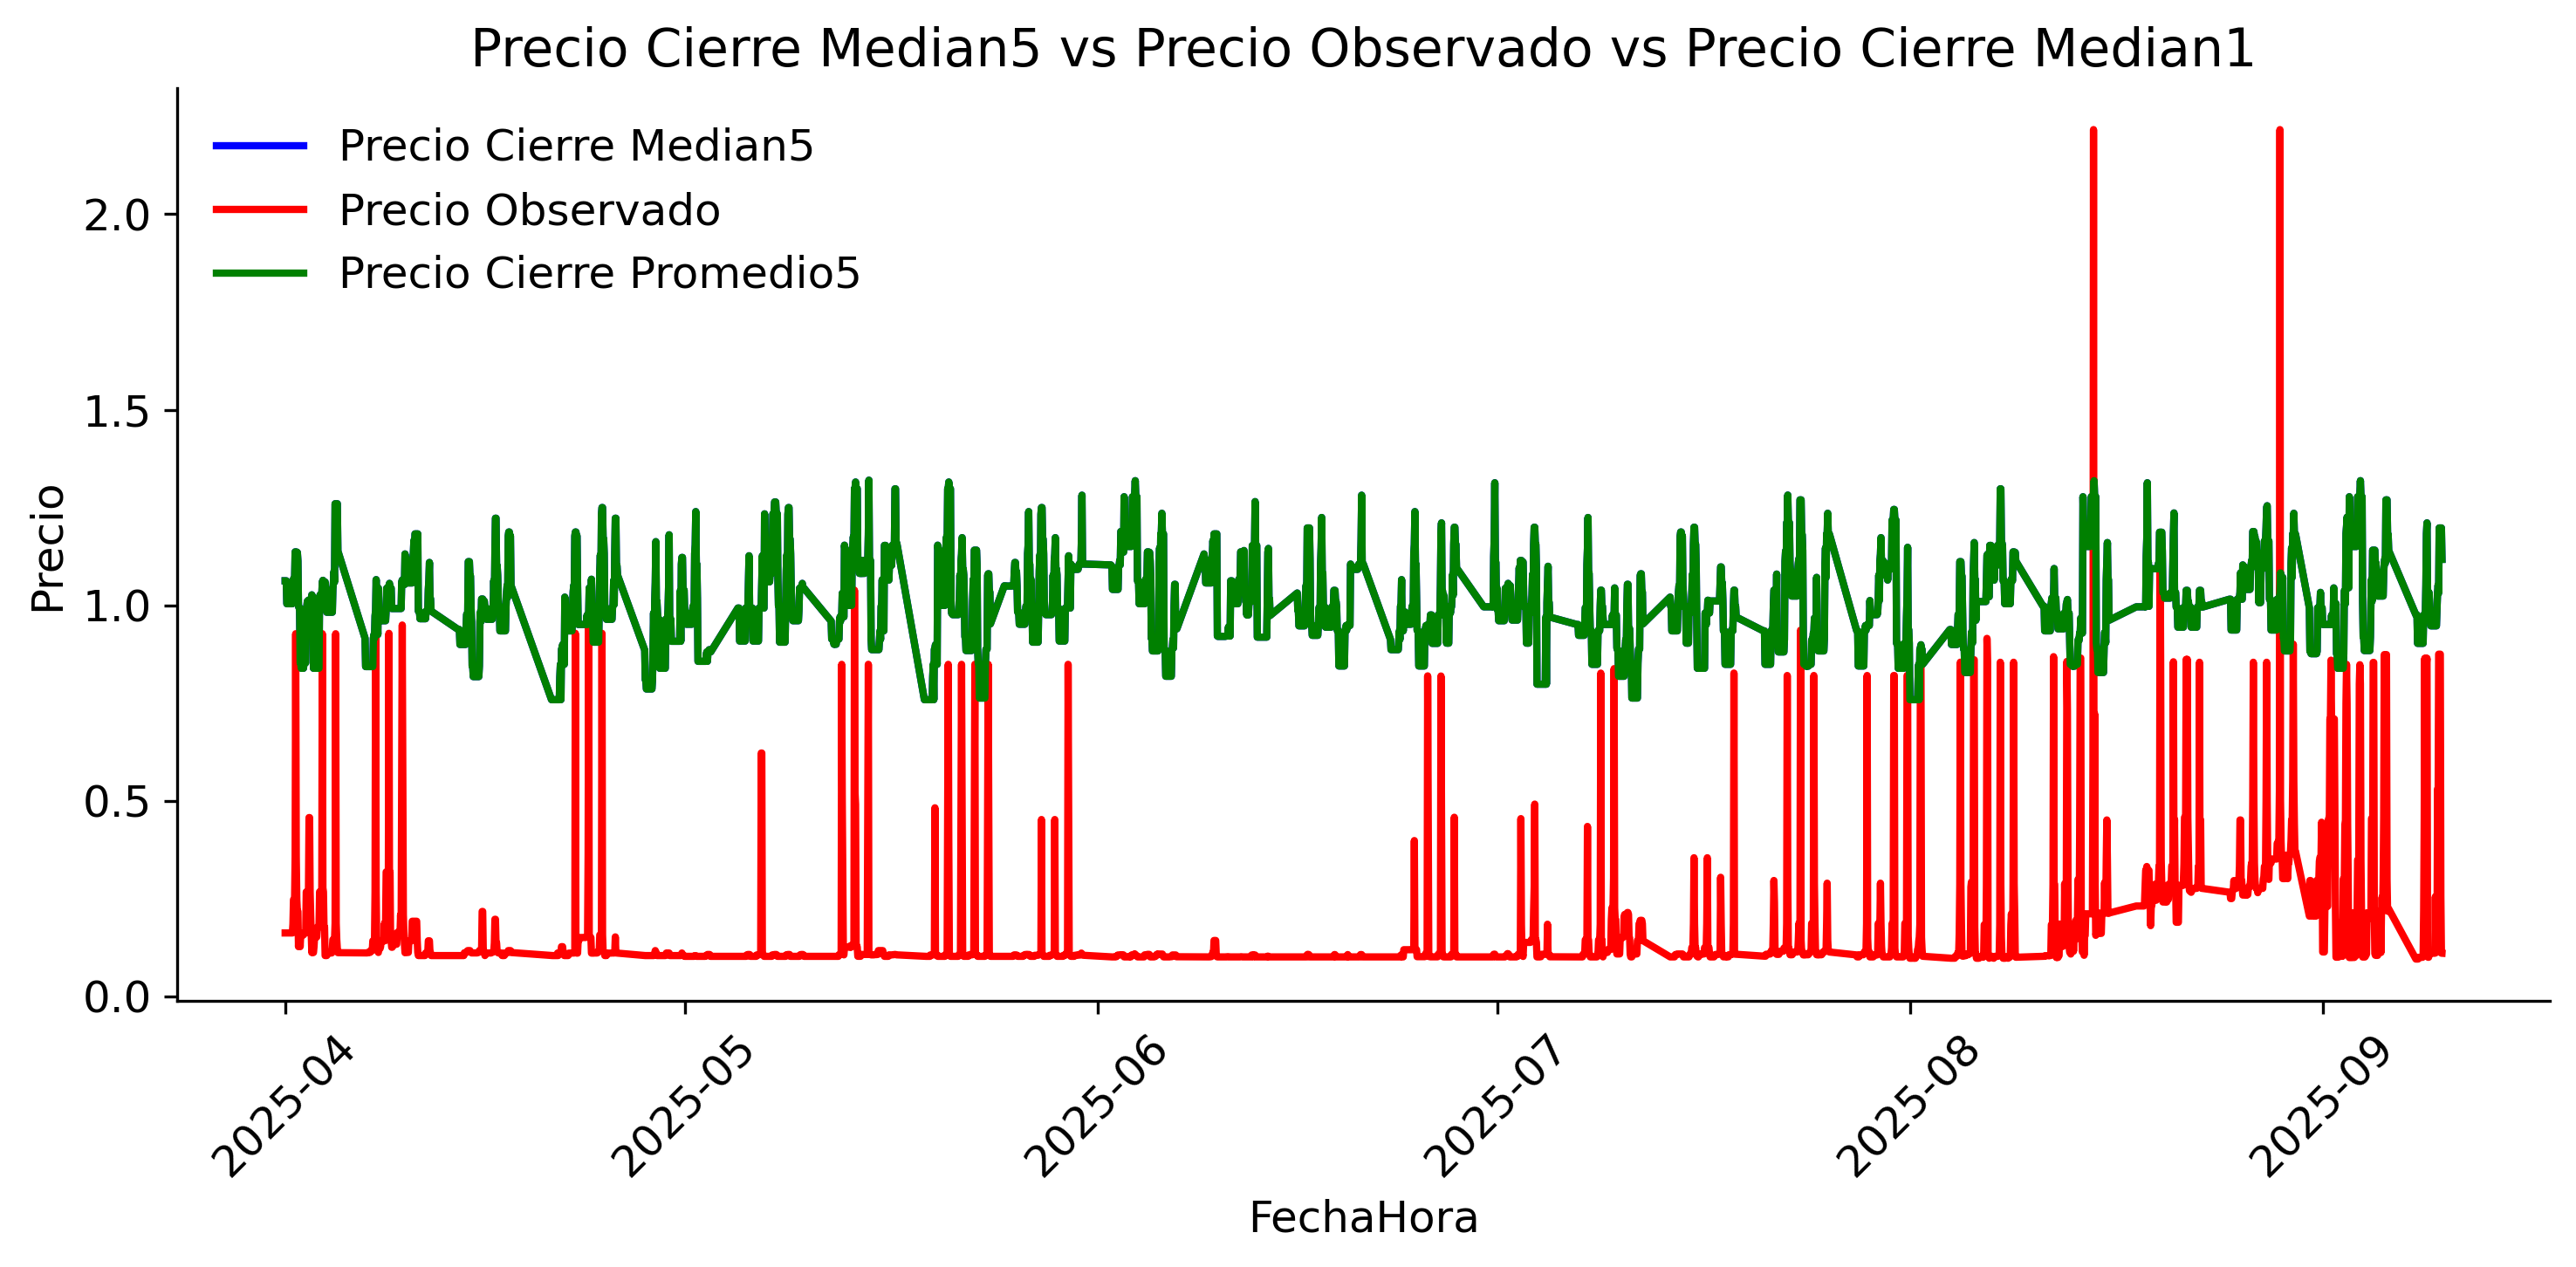

In [69]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})

plt.figure(figsize=(10,5), dpi=300)

plt.plot(precioCierreComparacion["FechaHora"], 
         precioCierreComparacion["precioCierreMedian5"], 
         label="Precio Cierre Median5", color="blue", linewidth=2)

plt.plot(precioCierreComparacion["FechaHora"], 
         precioCierreComparacion["precioObservado"], 
         label="Precio Observado", color="red", linewidth=2)

plt.plot(precioCierreComparacion["FechaHora"], 
         precioCierreComparacion["precioCierrePromedio5"], 
         label="Precio Cierre Promedio5", color="green", linewidth=2)



plt.xlabel("FechaHora")
plt.ylabel("Precio")
plt.title("Precio Cierre Median5 vs Precio Observado vs Precio Cierre Median1")
plt.legend(frameon=False)
plt.grid(False)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()